# Verificación de la desigualdad de parabolicidad (Capa 1)

Este notebook corre `ParabolicityVerifier` sobre los símbolos concretos del
proyecto (`HeatSymbol`, `FractionalLaplacianSymbol`, y los contraejemplos en
`counterexample.py`) para:

1. Estimar la constante $\kappa$ para cada símbolo, dado un $\omega$ fijo.
2. Ver cómo cambia $\kappa$ al variar $\omega$ (curva $\kappa_{\min}(\omega)$).
3. Visualizar el cociente $r(\mathbf{k},\lambda) = \|(a(\mathbf{k})+\lambda Id)^{-1}\| \cdot (1+|(\mathbf{k},\lambda)|^2)^{m/2}$
   como un heatmap, para confirmar visualmente que nunca cruza $\kappa$.
4. Contrastar con los contraejemplos, donde la desigualdad *no* se sostiene.

> **Ajusta la celda de imports** si tus nombres de clase o de módulo difieren
> de los que se usan aquí (`Symbol`, `ParabolicityVerifier`, `HeatSymbol`,
> `FractionalLaplacianSymbol`, `SlowDecaySymbol`, `PurelyImaginarySymbol`).


In [1]:
import sys
sys.path.insert(0, "../src")  #ruta para las clases

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from parabolic_symbol.Symbol import Symbol
from parabolic_symbol.ParabolicityVerifier import ParabolicityVerifier

from parabolic_symbol.symbols.heat import HeatSymbol
from parabolic_symbol.symbols.fractional_laplacian import FractionalLaplacianSymbol
from parabolic_symbol.symbols.counterexample import PurelyImaginarySymbol, SlowDecaySymbol

np.set_printoptions(precision=4, suppress=True)

## Utilidades de rejilla

`k_grid` genera todos los $\mathbf{k}\in\mathbb{Z}^n$ dentro de un rango, y
`default_lam_values` da un conjunto razonable de $\lambda$ con
$\mathrm{Re}(\lambda)\ge 0$ (más algunos valores para ver el comportamiento
al crecer).

In [2]:
def k_grid(n: int, k_max: int):
    return [np.array(idx) - k_max for idx in np.ndindex(*((2 * k_max + 1,) * n))]


def default_lam_values(re_values=(0, 1, 5, 10), im_values=(-5, 0, 5)):
    return [complex(re, im) for re in re_values for im in im_values]


## 1. Símbolo del calor: $a(\mathbf{k}) = |\mathbf{k}|^2$

Caso base, $m=2$, $E=\mathbb{C}$.

In [3]:
heat = HeatSymbol(n=1)
verifier_heat = ParabolicityVerifier(heat)

k_values = k_grid(n=1, k_max=20)
lam_values = default_lam_values()
omega = 1.0

kappa_hat = verifier_heat.estimate_kappa(k_values, lam_values, omega=omega)
results = verifier_heat.check_region(k_values, lam_values, omega=omega, kappa=kappa_hat * 1.05)

print(f"{heat!r}")
print(f"kappa_hat (omega={omega}) ~= {kappa_hat:.4f}")
print(f"Se cumple en toda la rejilla muestreada: {all(r.holds for r in results)}")


HeatSymbol(n=1, m=2.0, rho=3, dim=1)
kappa_hat (omega=1.0) ~= 2.0000
Se cumple en toda la rejilla muestreada: True


## 2. Laplaciano fraccionario: $a(\mathbf{k}) = |\mathbf{k}|^\alpha$

Repetimos para varios $\alpha$ y juntamos los resultados en una tabla.

In [4]:
frac_results = []

for alpha in [0.5, 1.0, 1.5, 2.0, 3.0]:
    symbol = FractionalLaplacianSymbol(n=1, alpha=alpha)
    verifier = ParabolicityVerifier(symbol)

    k_values_nz = [k for k in k_grid(n=1, k_max=20) if k[0] != 0]  # evitar |k|=0
    kappa_hat = verifier.estimate_kappa(k_values_nz, lam_values, omega=omega)
    results = verifier.check_region(k_values_nz, lam_values, omega=omega, kappa=kappa_hat * 1.05)

    frac_results.append({
        "alpha": alpha,
        "m": symbol.m,
        "kappa_hat": kappa_hat,
        "holds": all(r.holds for r in results),
    })

pd.DataFrame(frac_results)


,alpha,m,kappa_hat,holds
0,0.5,0.5,1.189207,True
1,1.0,1.0,1.414214,True
2,1.5,1.5,1.681793,True
3,2.0,2.0,2.000000,True
4,3.0,3.0,2.828427,True


## 3. Curva $\kappa_{\min}(\omega)$

Cómo cambia la $\kappa$ estimada al variar $\omega$ (el radio a partir del
cual se exige la desigualdad). Es esperable que $\kappa$ crezca al bajar
$\omega$, porque el dominio incluye puntos más cercanos al origen, donde el
cociente puede ser más grande.

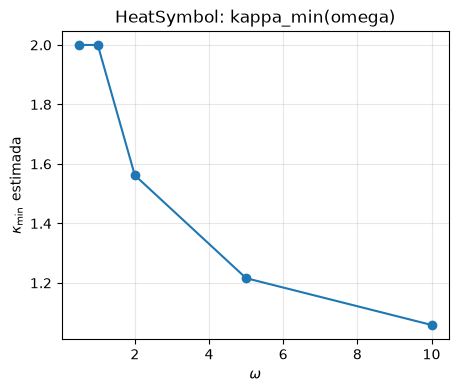

In [5]:
omega_values = [0.5, 1.0, 2.0, 5.0, 10.0]
k_values_wide = k_grid(n=1, k_max=25)

curve = []
for om in omega_values:
    kh = verifier_heat.estimate_kappa(k_values_wide, lam_values, omega=om)
    curve.append(kh)

plt.figure(figsize=(5, 4))
plt.plot(omega_values, curve, marker="o")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$\kappa_{\min}$ estimada")
plt.title("HeatSymbol: kappa_min(omega)")
plt.grid(True, alpha=0.3)
plt.show()


## 4. Heatmap del cociente $r(\mathbf{k},\lambda)$

Para $n=1$, fijamos $\mathrm{Im}(\lambda)$ en una rejilla y $\mathbf{k}$ en
otra, y mostramos $r(\mathbf{k},\lambda) = \|(a(\mathbf{k})+\lambda Id)^{-1}\|\cdot(1+|(\mathbf{k},\lambda)|^2)^{m/2}$.
Si el símbolo es parabólico, este mapa debe quedar acotado por $\kappa$ en
toda la región con $|(\mathbf{k},\lambda)|\ge\omega$.

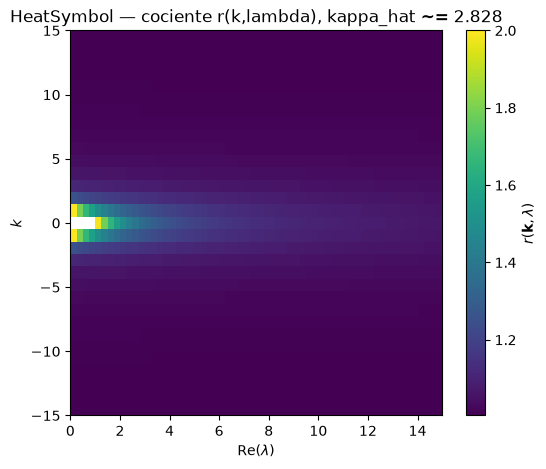

In [6]:
k_range = np.arange(-15, 16)
re_range = np.linspace(0, 15, 60)   # Re(lambda) >= 0
im_fixed = 0.0

ratio_grid = np.full((len(k_range), len(re_range)), np.nan)

for i, k in enumerate(k_range):
    for j, re in enumerate(re_range):
        lam = complex(re, im_fixed)
        phase_norm = verifier_heat.phase_space_norm(np.array([k]), lam)
        if phase_norm < omega:
            continue
        res_norm = verifier_heat.operator_norm(verifier_heat.resolvent(np.array([k]), lam))
        ratio_grid[i, j] = res_norm * (1.0 + phase_norm**2) ** (heat.m / 2.0)

plt.figure(figsize=(6, 5))
im = plt.imshow(
    ratio_grid,
    extent=[re_range.min(), re_range.max(), k_range.min(), k_range.max()],
    origin="lower", aspect="auto", cmap="viridis",
)
plt.colorbar(im, label=r"$r(\mathbf{k},\lambda)$")
plt.xlabel(r"$\mathrm{Re}(\lambda)$")
plt.ylabel(r"$k$")
plt.title(f"HeatSymbol — cociente r(k,lambda), kappa_hat ~= {kappa_hat:.3f}")
plt.show()


## 5. Contraejemplo: `PurelyImaginarySymbol`

Este símbolo falla algo más fuerte que la cota: en $\lambda = -i|\mathbf{k}|$
(que cumple $\mathrm{Re}(\lambda)=0$, dentro del dominio exigido),
$a(\mathbf{k})+\lambda Id$ deja de ser invertible.

In [7]:
imag_symbol = PurelyImaginarySymbol(n=1)
verifier_imag = ParabolicityVerifier(imag_symbol)

k_critical = np.array([3.0])
lam_critical = -1j * 3.0

try:
    verifier_imag.resolvent(k_critical, lam_critical)
    print("No fallo (revisa el simbolo / la implementacion).")
except np.linalg.LinAlgError as e:
    print(f"Fallo de invertibilidad, como se esperaba:\n  {e}")


Fallo de invertibilidad, como se esperaba:
  a(k) + lambda*Id no es invertible en k=[3.], lambda=(-0-3j)


## 7. Tabla resumen

Consolidamos las constantes estimadas para los símbolos "buenos" — esto es
lo que le puedes mostrar a tu asesor como evidencia numérica.

In [8]:
summary_rows = [
    {"simbolo": repr(heat), "m": heat.m, "rho": heat.rho, "omega": omega, "kappa_hat": kappa_hat},
]
for row in frac_results:
    summary_rows.append({
        "simbolo": f"FractionalLaplacianSymbol(alpha={row['alpha']})",
        "m": row["m"], "rho": None, "omega": omega, "kappa_hat": row["kappa_hat"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,simbolo,m,rho,omega,kappa_hat
0,"HeatSymbol(n=1, m=2.0, rho=3, dim=1)",2.0,3.0,1.0,2.828427
1,FractionalLaplacianSymbol(alpha=0.5),0.5,NaN,1.0,1.189207
2,FractionalLaplacianSymbol(alpha=1.0),1.0,NaN,1.0,1.414214
3,FractionalLaplacianSymbol(alpha=1.5),1.5,NaN,1.0,1.681793
4,FractionalLaplacianSymbol(alpha=2.0),2.0,NaN,1.0,2.000000
5,FractionalLaplacianSymbol(alpha=3.0),3.0,NaN,1.0,2.828427


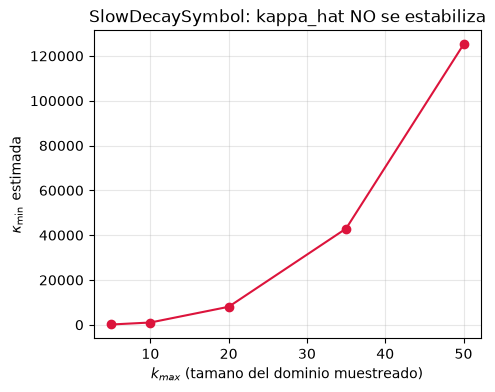

In [9]:
slow = SlowDecaySymbol(n=1)
verifier_slow = ParabolicityVerifier(slow)
lam_zero = [complex(0, 0)]

k_max_values = [5, 10, 20, 35, 50]
kappa_vs_kmax = []
for k_max in k_max_values:
    kh = verifier_slow.estimate_kappa(k_grid(n=1, k_max=k_max), lam_zero, omega=1.0)
    kappa_vs_kmax.append(kh)

plt.figure(figsize=(5, 4))
plt.plot(k_max_values, kappa_vs_kmax, marker="o", color="crimson")
plt.xlabel(r"$k_{max}$ (tamano del dominio muestreado)")
plt.ylabel(r"$\kappa_{\min}$ estimada")
plt.title("SlowDecaySymbol: kappa_hat NO se estabiliza")
plt.grid(True, alpha=0.3)
plt.show()


## 8. Heatmap de `SlowDecaySymbol`

Como `SlowDecaySymbol` tiene crecimiento $|k|$ pero declara orden $m=4$, el
cociente $r(\mathbf{k},\lambda)$ crece sin cota. Usamos escala logarítmica
para hacer visible su crecimiento y dibujamos la línea $r=1$ como referencia.

In [ ]:
slow = SlowDecaySymbol(n=1)
verifier_slow = ParabolicityVerifier(slow)
k_range_slow = np.arange(-30, 31)
re_range_slow = np.linspace(0, 15, 80)
im_fixed_slow = 0.0

ratio_slow = np.full((len(k_range_slow), len(re_range_slow)), np.nan)
for i, k_value in enumerate(k_range_slow):
    for j, re_value in enumerate(re_range_slow):
        lam_value = complex(re_value, im_fixed_slow)
        phase_norm_slow = verifier_slow.phase_space_norm(np.array([k_value]), lam_value)
        if phase_norm_slow < omega:
            continue
        try:
            resolvent_norm_slow = verifier_slow.operator_norm(
                verifier_slow.resolvent(np.array([k_value]), lam_value)
            )
        except np.linalg.LinAlgError:
            continue
        ratio_slow[i, j] = resolvent_norm_slow * (
            1.0 + phase_norm_slow**2
        ) ** (slow.m / 2.0)

log_ratio_slow = np.log10(ratio_slow)
finite_log_ratio_slow = log_ratio_slow[np.isfinite(log_ratio_slow)]

plt.figure(figsize=(7, 5))
im_slow = plt.imshow(
    log_ratio_slow,
    extent=[re_range_slow.min(), re_range_slow.max(), k_range_slow.min(), k_range_slow.max()],
    origin="lower",
    aspect="auto",
    cmap="magma",
    vmin=finite_log_ratio_slow.min(),
    vmax=finite_log_ratio_slow.max(),
)
plt.colorbar(im_slow, label=r"$\log_{10} r(k,\lambda)$")
plt.contour(
    re_range_slow,
    k_range_slow,
    log_ratio_slow,
    levels=[0],
    colors="cyan",
    linewidths=1.5,
)
plt.xlabel(r"$\mathrm{Re}(\lambda)$")
plt.ylabel(r"$k$")
plt.title("SlowDecaySymbol — cociente no acotado")
plt.tight_layout()
plt.show()

print(f"r minimo en la rejilla: {np.nanmin(ratio_slow):.4g}")
print(f"r maximo en la rejilla: {np.nanmax(ratio_slow):.4g}")